<a href="https://colab.research.google.com/github/sungmin-Jeon/financial_practice-/blob/main/notebooks/VAR(Vector_Autoregressive).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VAR 모형 정리 및 실습

본 노트북에서는 다변량 시계열 모형인 VAR을 중심으로,
정상 시계열과 비정상 시계열에 따라 적절한 모형을 선택하는 전체 흐름을 실습을 통해 이해한다.

특히 비정상 시계열의 경우 공적분 여부에 따라
차분 VAR 또는 VECM을 선택하는 과정에 초점을 둔다.

## 0. 라이브러리

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.stattools import adfuller

import statsmodels.api as sm


## 1. VAR 모형이란?

VAR(Vector Autoregression) 모형은 여러 시계열이 서로에게 미치는 영향을 동시에 분석하기 위한 다변량 시계열 모형이다.

각 변수는 자신의 과거값뿐만 아니라 다른 변수들의 과거값에도 영향을 받는다.

따라서 VAR 모형은 다수의 시계열 간 동적 관계를 분석하는 데 활용된다.

## 2. 다변량 시계열 분석 절차

VAR 모형을 적용하기 위해서는 다음과 같은 절차를 따른다.

1. 각 시계열의 정상성 확인 (ADF test)
2. 정상 시계열이면 VAR 모형 적용
3. 비정상 시계열이면 공적분 여부 확인
4. 공적분이 없으면 차분 후 VAR 적용
5. 공적분이 있으면 VECM 적용

즉, 시계열의 특성에 따라 적절한 모형을 선택하는 것이 중요하다.

## 3. 실습 구성

본 실습에서는 다음 3가지 경우를 비교한다.

1. 정상 시계열 → VAR
2. 비정상 시계열 (공적분 없음) → 차분 VAR
3. 비정상 시계열 (공적분 존재) → VECM

이를 통해 모형 선택 기준을 직접 확인한다.

## 4. 실습 1: 정상 시계열

정상 시계열을 생성한 후 ADF 검정을 통해 정상성을 확인하고,
VAR 모형을 적용한다.

### 4-1. 정상 시계열 데이터 생성 및 시각화

,x,y
0,0.000000,0.000000
1,-0.138264,-0.560181
2,0.578556,0.523934
3,1.812308,0.998973
4,0.672001,1.003713


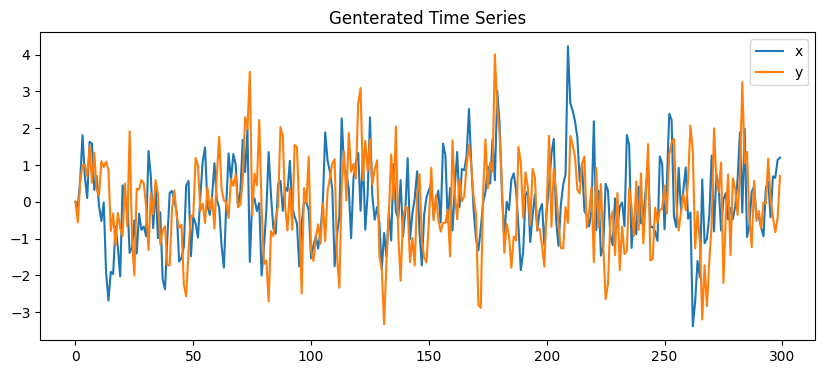

In [29]:
np.random.seed(42)

n = 300
x = np.zeros(n)
y = np.zeros(n)

e1 = np.random.normal(0, 1, n)
e2 = np.random.normal(0, 1, n)

for t in range(1, n):
    x[t] = 0.5 * x[t-1] + e1[t]
    y[t] = 0.3 * y[t-1] + 0.4 * x[t-1] + e2[t]

df = pd.DataFrame({
    "x": x,
    "y": y
})

display(df.head())

plt.figure(figsize=(10, 4))
plt.plot(df["x"], label="x")
plt.plot(df["y"], label="y")
plt.title("Genterated Time Series")
plt.legend()
plt.show()

### 4-2. ADF 검정을 통한 정상성 확인

In [30]:
def adf_test(series, name):
    result = adfuller(series)
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    if result[1] < 0.05:
        print("=> 정상 시계열로 볼 가능성이 높음\n")
    else:
        print("=> 비정상 시계열일 가능성이 있음\n")

adf_test(df["x"], "x")
adf_test(df["y"], "y")

--- ADF Test: x ---
ADF Statistic: -10.8952
p-value: 0.0000
Critical Values:
   1%: -3.4524
   5%: -2.8713
   10%: -2.5719
=> 정상 시계열로 볼 가능성이 높음

--- ADF Test: y ---
ADF Statistic: -10.9842
p-value: 0.0000
Critical Values:
   1%: -3.4524
   5%: -2.8713
   10%: -2.5719
=> 정상 시계열로 볼 가능성이 높음



### 4-3. VAR모형 적합
### x, y의 생성식을 알고 있으므로 이 예제에서는 VAR(1)이 적절하다는 것을 미리 알고 있다. 그러나 실제 데이터에서는 생성 과정을 알 수 없기 때문에, AIC나 BIC와 같은 정보기준을 비교하여 값이 가장 작은 lag를 선택해야 한다.

#### 4-3-1. 추정된 VAR(1) 모형

#### x 방정식
$$
x_t = -0.008239 + 0.422963 x_{t-1} + 0.016746 y_{t-1} + \varepsilon_{1,t}
$$

- x의 1시점 전 값의 계수는 0.422963이며 통계적으로 유의하다(p=0.000).
- y의 1시점 전 값의 계수는 0.016746이지만 통계적으로 유의하지 않다(p=0.729).
- 따라서 x는 주로 자기 자신의 과거값에 의해 설명된다고 볼 수 있다.

#### y 방정식
$$
y_t = -0.015179 + 0.505938 x_{t-1} + 0.328553 y_{t-1} + \varepsilon_{2,t}
$$

- x의 1시점 전 값의 계수는 0.505938이며 통계적으로 유의하다(p=0.000).
- y의 1시점 전 값의 계수는 0.328553이며 통계적으로 유의하다(p=0.000).
- 따라서 y는 자기 자신의 과거값과 x의 과거값 모두에 의해 설명된다고 볼 수 있다.

### 오차의 상관계수 행렬
- 두 오차의 상관계수는 매우 낮으므로 오차는 거의 독립적이다.
- 즉, 모델이 설명 못한 공통 충격이 거의 없다.

In [31]:
model = VAR(df)
lag_order_results = model.select_order(maxlags=10)
print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       0.5215      0.5468       1.685      0.5317
1    -0.07437*   0.001557*     0.9283*   -0.04395*
2     -0.05862     0.06792      0.9431   -0.007923
3     -0.04390      0.1333      0.9571     0.02708
4     -0.03476      0.1930      0.9659     0.05650
5     -0.03128      0.2471      0.9693     0.08026
6     -0.01563      0.3134      0.9846      0.1162
7    -0.005745      0.3739      0.9945      0.1464
8      0.01224      0.4425       1.013      0.1846
9      0.02811      0.5090       1.029      0.2208
10     0.03694      0.5684       1.038      0.2499
--------------------------------------------------


In [32]:
results = model.fit(1) # VAR(1)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 22, Apr, 2026
Time:                     08:56:18
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                 -0.0242078
Nobs:                     299.000    HQIC:                -0.0687434
Log likelihood:          -827.805    FPE:                   0.906229
AIC:                   -0.0984642    Det(Omega_mle):        0.888314
--------------------------------------------------------------------
Results for equation x
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.008239         0.057025           -0.144           0.885
L1.x          0.422963         0.053830            7.857           0.000
L1.y          0.016746         0.048360            0.346           0.729

Results for equation y

#### 4-3-2. 오차의 분산-공분산 행렬
- 분산의 경우 0.91 정도로 설계된 정도이며
- 공분산의 경우 0에 가까워 두 오차가 독립임을 알 수 있다.

          x         y
1 -0.130025 -0.545002
2  0.654657  0.793115
3  1.567065  0.549298
4 -0.103029 -0.226238
5 -0.190937  0.032657


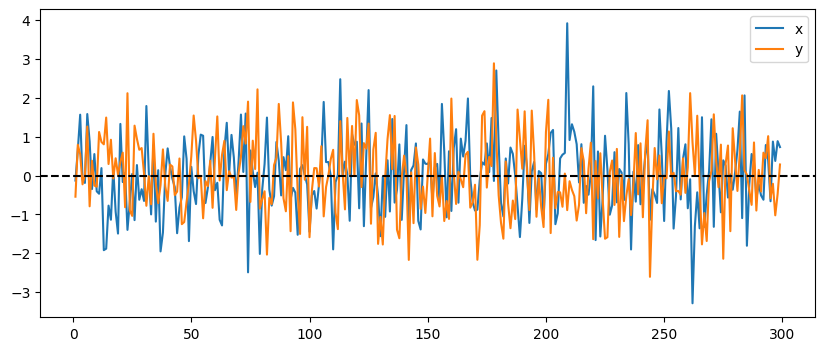

오차의 분산-공분산 행렬 Σ:
          x         y
x  0.970872 -0.028292
y -0.028292  0.915790


In [33]:
residuals = results.resid
print(residuals.head())

residuals.plot(figsize=(10,4))
plt.axhline(0, color='black', linestyle='--')
plt.show()

print("오차의 분산-공분산 행렬 Σ:")
print(results.sigma_u)

### 4-4. Granger causality 확인
### Granger casuality란?
- x의 과거값이 y를 예측하는 데 추가로 도움이 되면, x가 y를 Granger-cause 한다고 말한다.
- 쉽게 말해, y 자신의 과거만 넣은 AR 모형보다, x의 과거값까지 추가했을 때 y 설명력이 유의하게 좋아지면 귀무가설을 기각한다.
  - 귀무가설: x 과거는 쓸모 없다
  - 기각: x 과거른 넣으면 예측이 좋아진다.
  - 결론 x가 y를 Granger-cause 한다
### Granger Causality 결과

- x → y 방향의 Granger causality 검정에서는 p-value가 유의수준 0.05보다 작게 나타나, x의 과거값이 y를 예측하는 데 유의한 정보를 제공함을 확인하였다.
- y → x 방향의 검정에서는 p-value가 0.05보다 크게 나타나, y의 과거값이 x를 예측하는 데 유의한 정보를 제공한다고 보기 어려웠다.
- 따라서 본 실습에서는 x가 y를 Granger-cause 하지만, y가 x를 Granger-cause 하지는 않는 것으로 해석할 수 있다.

In [35]:
print(results.test_causality("y", ["x"], kind="f")) # x가 y를 설명하는지
print(results.test_causality("x", ["y"], kind="f")) # y가 x를 설명하는

<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: x does not Granger-cause y: reject at 5% significance level. Test statistic: 93.650, critical value: 3.857>, p-value: 0.000>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: y does not Granger-cause x: fail to reject at 5% significance level. Test statistic: 0.120, critical value: 3.857>, p-value: 0.729>


## 5. 실습2: 비정상 시계열 (공적분 없음)
이번에는 서로 독립적인 랜덤워크 시계열을 생성한다.
이 경우 각 시계열은 개별적으로 비정상성을 가지며, 두 시계열 사이에 장기적인 균형 관계(공적분)는 존재하지 않는다.
따라서 공적분 검정 결과 공적분이 없다고 판단되면, 차분을 통해 정상성을 확보한 뒤 VAR모형을 적용해야 한다.

### 5-1. 비정상 시계열 데이터 생성 및 시각화

,x,y
0,0.000000,0.000000
1,-0.138264,-0.560181
2,0.509424,0.187113
3,2.032454,0.797483
4,1.798301,0.776581


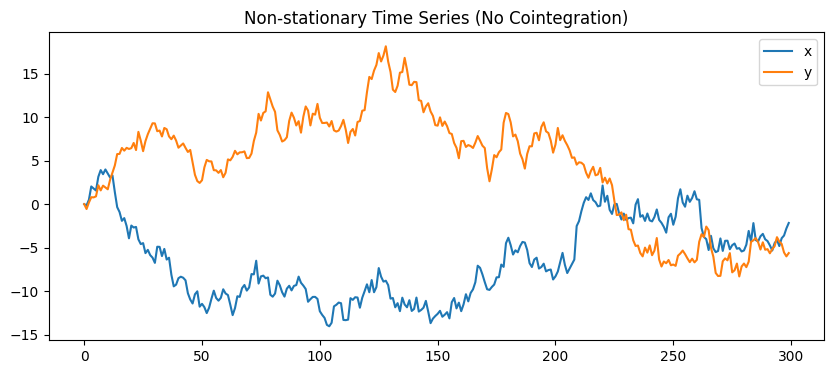

In [36]:
np.random.seed(42)

n = 300
x = np.zeros(n)
y = np.zeros(n)

e1 = np.random.normal(0, 1, n)
e2 = np.random.normal(0, 1, n)

for t in range(1, n):
    x[t] = x[t-1] + e1[t]
    y[t] = y[t-1] + e2[t]

df_ns = pd.DataFrame({
    "x": x,
    "y": y
})

display(df_ns.head())

df_ns.plot(figsize=(10,4))
plt.title("Non-stationary Time Series (No Cointegration)")
plt.show()

### 5-2. ADF 검정을 통한 정상성 확인
ADF 검정의 귀무가설은 "단위근이 존재한다", 즉 비정상 시계열이라는 것이다. 따라서 p-value가 충분히 작아야 정상 시계열로 판단 -> p-value > 0.05 따라서 귀무가설을 채택한다.

In [37]:
adf_test(df_ns["x"], "x")
adf_test(df_ns["y"], "y")

--- ADF Test: x ---
ADF Statistic: -1.9084
p-value: 0.3281
Critical Values:
   1%: -3.4525
   5%: -2.8713
   10%: -2.5720
=> 비정상 시계열일 가능성이 있음

--- ADF Test: y ---
ADF Statistic: -0.9053
p-value: 0.7862
Critical Values:
   1%: -3.4524
   5%: -2.8713
   10%: -2.5719
=> 비정상 시계열일 가능성이 있음



### 5-3. 공적분 검정
두 시계열이 모두 비정상이라고 해서 항상 장기 관계가 존재하는 것은 아니다. 따라서 공적분 검정을 통해 두 시계열 사이에 장기 균현 관계가 존재하는지 확인한다.

In [38]:
from statsmodels.tsa.stattools import coint

score, pvalue, _ = coint(df_ns["x"], df_ns["y"])

print("Cointegration test statistic:", score)
print("p-value:", pvalue)

if pvalue < 0.05:
    print("=> 공적분 관계가 존재할 가능성이 높음")
else:
    print("=> 공적분 관계가 없을 가능성이 높음")

Cointegration test statistic: -2.803416402815864
p-value: 0.1646000755863341
=> 공적분 관계가 없을 가능성이 높음


### 5-4. 차분을 통한 정상성 확보
공적분이 존재하지 않는 비정상 시계열의 경우, 차분을 통해 정상성을 확보한 뒤 VAR모형을 적용한다.

,x,y
1,-0.138264,-0.560181
2,0.647689,0.747294
3,1.523030,0.610370
4,-0.234153,-0.020902
5,-0.234137,0.117327


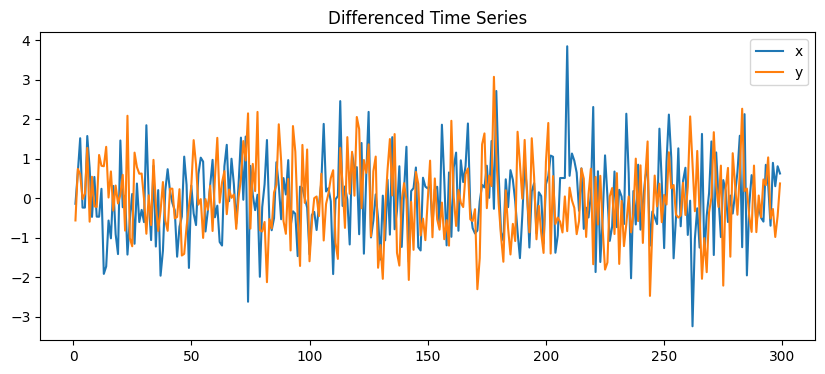

In [39]:
df_ns_diff = df_ns.diff().dropna()
display(df_ns_diff.head())

df_ns_diff.plot(figsize=(10,4))
plt.title("Differenced Time Series")
plt.show()

In [40]:
adf_test(df_ns_diff["x"], "diff_x")
adf_test(df_ns_diff["y"], "diff_y")

--- ADF Test: diff_x ---
ADF Statistic: -18.5895
p-value: 0.0000
Critical Values:
   1%: -3.4525
   5%: -2.8713
   10%: -2.5720
=> 정상 시계열로 볼 가능성이 높음

--- ADF Test: diff_y ---
ADF Statistic: -16.1872
p-value: 0.0000
Critical Values:
   1%: -3.4525
   5%: -2.8713
   10%: -2.5720
=> 정상 시계열로 볼 가능성이 높음



### 5-5. 차분 VAR 모형 적합
차분 VAR(1) 모형 적합 결과, x 방정식에서는 자기 자신의 시차항과 y의 시차항 모두 유의하지 않았다.
반면 y 방정식에서는 x의 1시차 항만 유의하게 나타났다(p=0.013).

즉, 본 표본에서는 x의 과거 변화가 y의 현재 변화를 설명하는 것으로 나타났으나,
y의 과거 변화는 x의 현재 변화에 유의한 영향을 주지 않았다.

그러나 본 데이터는 생성 과정상 서로 독립적인 랜덤워크를 차분한 것이므로,
이론적으로는 유의한 관계가 나타나지 않아야 한다.
따라서 이러한 결과는 표본의 우연한 변동에 의한 것일 가능성도 고려해야 한다.

In [41]:
model_ns = VAR(df_ns_diff)
results_ns = model_ns.select_order(maxlags=10)

print(results_ns.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0     -0.07127   -0.04590*      0.9312   -0.06110*
1    -0.07623*  -0.0001119     0.9266*    -0.04573
2     -0.05399     0.07287      0.9474   -0.003160
3     -0.04508      0.1325      0.9559     0.02609
4     -0.04105      0.1873      0.9598     0.05045
5     -0.02374      0.2554      0.9766     0.08810
6    -0.001541      0.3283      0.9986      0.1306
7   -0.0002257      0.3804       1.000      0.1523
8      0.01738      0.4487       1.018      0.1902
9      0.04275      0.5248       1.044      0.2359
10     0.05410      0.5869       1.056      0.2676
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [42]:
results_ns = model_ns.fit(1) # VAR(1)
print(results_ns.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 22, Apr, 2026
Time:                     08:58:31
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                 -0.0252459
Nobs:                     298.000    HQIC:                -0.0698871
Log likelihood:          -824.834    FPE:                   0.905125
AIC:                   -0.0996840    Det(Omega_mle):        0.887172
--------------------------------------------------------------------
Results for equation x
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.006988         0.057194           -0.122           0.903
L1.x         -0.076924         0.058113           -1.324           0.186
L1.y          0.025880         0.059496            0.435           0.664

Results for equation y

### 5-6. Granger casuality 검정
Granger causality 검정 결과, x의 과거값은 y를 예측하는 데 유의한 정보를 제공하는 것으로 나타났다(p=0.013).
반면 y의 과거값은 x를 예측하는 데 유의하지 않았다(p=0.664).

따라서 본 표본에서는 x → y 방향의 Granger causality가 관찰되었으나,
데이터 생성 구조상 두 시계열은 독립적으로 생성되었으므로 해당 결과는 표본 변동에 의한 우연한 유의성일 가능성도 존재한다.

In [43]:
print(results_ns.test_causality("y", ["x"], kind="f"))
print(results_ns.test_causality("x", ["y"], kind="f"))

<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: x does not Granger-cause y: reject at 5% significance level. Test statistic: 6.180, critical value: 3.857>, p-value: 0.013>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: y does not Granger-cause x: fail to reject at 5% significance level. Test statistic: 0.189, critical value: 3.857>, p-value: 0.664>


### 5-7. 결과 해석
차분 VAR 모형 적합 결과와 Granger causality 검정 결과는 일관된 방향을 보였다.
VAR 결과에서 x의 1시차 항은 y 방정식에서 유의하게 나타났고,
Granger causality 검정에서도 x는 y를 예측하는 데 유의한 정보를 제공하는 것으로 나타났다.

따라서 본 표본에서는 x의 과거 변화가 y의 현재 변화를 설명하는 방향성이 관찰되었다.

다만 본 데이터는 생성 과정상 독립적인 랜덤워크를 차분한 것이므로,
이 결과는 표본 변동에 의한 우연한 유의성일 가능성도 함께 고려해야 한다.

## 6. 실습3: 비정상 시계열 (공적분 있음)
이번에는 각 시계열은 개별적으로 비정상성을 가지지만, 서로 장기적으로 함께 움직이도록 데이터를 생성한다.
즉, 각 시계열은 단위근을 가지는 비정상 시계열이지만, 두 시계열의 특정 선형결합은 정상성을 가지도록 하여 공적분 관계가 존재하도록 한다.
이 경우 단순히 차분 후 VAR모형을 적용하는 것이 아니라, 장기 균형 관계와 단기 조정 과정을 함께 반영할 수 있는 VECM 모형을 적용하는 것이 적절하다.

### 6-1. 공적분 관계를 가지는 비정상 시계열 생성 및 시각화

,x,y
0,0.000000,-0.414498
1,-0.138264,-0.418355
2,0.509424,0.883071
3,2.032454,2.337639
4,1.798301,1.787850


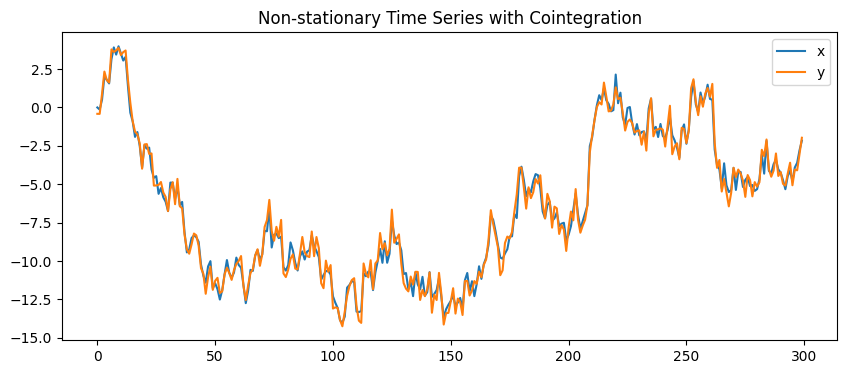

In [52]:
np.random.seed(42)

n = 300
x = np.zeros(n)
u = np.random.normal(0, 1, n)
e = np.random.normal(0, 0.5, n)

for t in range(1, n):
    x[t] = x[t-1] + u[t]

y = x + e

df_coint = pd.DataFrame({
    "x": x,
    "y": y
    })
display(df_coint.head())

df_coint.plot(figsize=(10,4))
plt.title("Non-stationary Time Series with Cointegration")
plt.show()

### 6-2. ADF 검정을 통한 정상성 확인
먼저 각 시계열이 개별적으로 정상인지 비정상인지 확인한다. ADF 검정의 귀무가설은 "단위근이 존재한다", 즉, 비정상 시계열이라는 것이다.

In [53]:
adf_test(df_coint["x"], "x")
adf_test(df_coint["y"], "y")

--- ADF Test: x ---
ADF Statistic: -1.9084
p-value: 0.3281
Critical Values:
   1%: -3.4525
   5%: -2.8713
   10%: -2.5720
=> 비정상 시계열일 가능성이 있음

--- ADF Test: y ---
ADF Statistic: -2.4862
p-value: 0.1189
Critical Values:
   1%: -3.4529
   5%: -2.8715
   10%: -2.5721
=> 비정상 시계열일 가능성이 있음



### 6-3. 공적분 검정
각 시계열은 비정상일 수 있지만, 두 시계열 사이에 장기적인 균형 관계가 존재한다면 공적분 관계가 있다고 볼 수 있다. 본 실습에서는 2변수 사례이므로 Engle-Granger 방식의 공적분 검정을 사용한다.
(Johansen 방식도 있음)

In [54]:
score, pvalue, _ = coint(df_coint["x"], df_coint["y"])

print("Cointegration test statistic:", score)
print("p-value:", pvalue)

if pvalue < 0.05:
    print("=> 공적분 관계가 존재할 가능성이 높음")
else:
    print("=> 공적분 관계가 없을 가능성이 높음")

Cointegration test statistic: -16.125331982679818
p-value: 3.737081183884339e-28
=> 공적분 관계가 존재할 가능성이 높음


### 6-4. 선형결합(Spread)의 정상성 확인
공적분이 존재한다면, 비정상 시계열들의 특정 선형결합은 정상성을 가져야 한다.

실제 데이터에서는 공적분 관계의 계수를 알 수 없으므로,
단순히 $ y_t - x_t $) 형태로 spread를 구성할 수 없다.

따라서 먼저 장기균형식을 회귀로 추정한 뒤, 그 추정식의 잔차를 spread로 사용한다.

즉, spread는 두 시계열의 단순 차이가 아니라 추정된 장기 균형 관계에서 벗어난 정도를 의미한다.

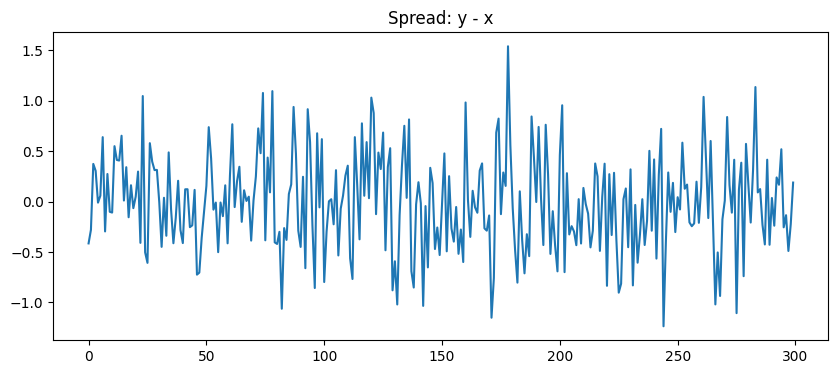

--- ADF Test: spread = y - x ---
ADF Statistic: -16.2017
p-value: 0.0000
Critical Values:
   1%: -3.4524
   5%: -2.8713
   10%: -2.5719
=> 정상 시계열로 볼 가능성이 높음



In [55]:
# 추정식을 실제로 아니까 가능한 spread
spread = df_coint["y"] - df_coint["x"]

plt.figure(figsize=(10,4))
plt.plot(spread)
plt.title("Spread: y - x")
plt.show()

adf_test(spread, "spread = y - x")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 2.664e+04
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          1.55e-293
Time:                        09:25:37   Log-Likelihood:                -205.41
No. Observations:                 300   AIC:                             414.8
Df Residuals:                     298   BIC:                             422.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0060      0.049      0.123      0.9

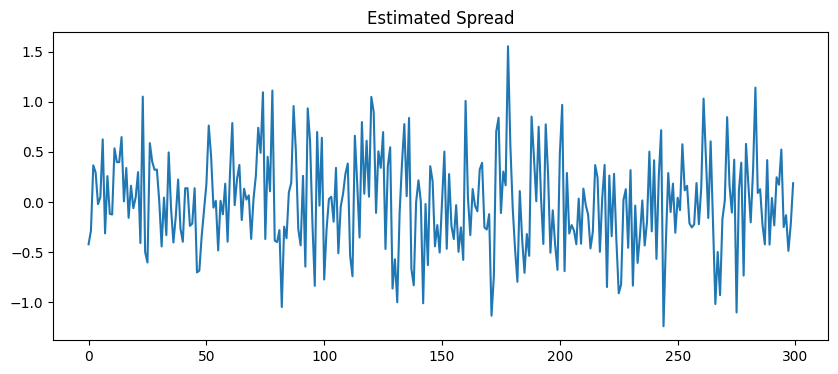

--- ADF Test: estimated spread ---
ADF Statistic: -16.2201
p-value: 0.0000
Critical Values:
   1%: -3.4524
   5%: -2.8713
   10%: -2.5719
=> 정상 시계열로 볼 가능성이 높음



In [57]:
# 1. 장기균형식 추정
X = sm.add_constant(df_coint["x"])
long_run_model = sm.OLS(df_coint["y"], X).fit()

print(long_run_model.summary())

# 2. 추정된 계수 확인
alpha = long_run_model.params["const"]
beta = long_run_model.params["x"]

# 3. spread 생성 (잔차)
spread_est = df_coint["y"] - alpha - beta * df_coint["x"]

# 4. 시각화
plt.figure(figsize=(10, 4))
plt.plot(spread_est)
plt.title("Estimated Spread")
plt.show()

# 5. 정상성 검정
adf_test(spread_est, "estimated spread")

### 6-5. VECM 모형적합
공적분이 존재하는 비정상 시계열의 경우, 단순 차분 VAR이 아니라 장기 균형 관계와 단기 조정 과넞ㅇ을 함께 포함하는 VECM(Vector Error Correction Model)모형을 적용한다.

In [62]:
from statsmodels.tsa.vector_ar.vecm import VECM

vecm_model = VECM(df_coint, k_ar_diff=1, coint_rank=1)
vecm_result = vecm_model.fit()

print(vecm_result.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation x
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.x          -0.1587      0.130     -1.219      0.223      -0.414       0.096
L1.y           0.0832      0.118      0.703      0.482      -0.149       0.315
Det. terms outside the coint. relation & lagged endog. parameters for equation y
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.x          -0.0880      0.143     -0.616      0.538      -0.368       0.192
L1.y           0.0817      0.130      0.628      0.530      -0.173       0.337
                 Loading coefficients (alpha) for equation x                  
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

### 6-6. 결과 해석

ADF 검정 결과 x와 y는 각각 비정상 시계열로 나타났다.
그러나 공적분 검정 결과 두 시계열 사이에는 장기적인 균형 관계가 존재하는 것으로 확인되었다.

또한 spread인 $( y_t - x_t $) 에 대해 ADF 검정을 수행한 결과 정상 시계열로 판단된다면,
이는 두 비정상 시계열의 선형결합이 정상성을 가진다는 뜻이므로 공적분 관계를 직관적으로 확인한 것이다.

따라서 이 경우에는 단순히 차분 후 VAR 모형을 적용하는 것이 아니라,
장기 균형 관계와 단기 조정 과정을 함께 반영할 수 있는 VECM 모형을 사용하는 것이 적절하다.

## 7. 전체 정리

이번 실습을 통해 다변량 시계열 분석의 모형 선택 기준을 다음과 같이 정리할 수 있다.

- 정상 시계열: VAR 적용
- 비정상 시계열 + 공적분 없음: 차분 후 VAR 적용
- 비정상 시계열 + 공적분 존재: VECM 적용

즉, 다변량 시계열 분석에서는 먼저 정상성과 공적분 여부를 확인한 뒤,
그 결과에 맞는 모형을 선택하는 것이 핵심이다.